In [426]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import h5py

import torch
import torch.nn as nn
from torch.utils.data import DataLoader,Dataset
import torch.optim as optim
import torch.nn.functional as F

import lava.lib.dl.slayer as slayer

from sklearn.model_selection import train_test_split

fs = 128 #Hz

# Dataset Class that read the Input EEG data
* The input EEG table will includes EEG data and label from the preprocessing stage.
* 23 Subjets, 18 Video (with emotion label), 14 channel in total.
* Sampling rate is 128 Hz, with the segement window to be 3 seconds.

The Dataset pre-processed to fetch all the channels in the same subject, video and segment.

In [427]:
# label transformation
def va_to_4class(v, a):
    if v == 1 and a == 1:
        return 1
    elif v == 1 and a == 0:
        return 2
    elif v == 0 and a == 1:
        return 3
    elif v == 0 and a == 0:
        return 4
    else:
        return 0

In [428]:
class EEGDataset(Dataset):
    def __init__(self, df,n_ch = 14, seg_len = 384):
        self.df = df
        self.n_ch = n_ch
        self.seg_len = seg_len

        # Each sample has its own sub, video, segment
        self.keys = df[["subject","video","segment"]].drop_duplicates().reset_index(drop=True)

    def __len__(self):
        return len(self.keys) # total sample length

    def __getitem__(self, idx):

        key = self.keys.iloc[idx]
        sub = key["subject"]
        vid = key["video"]
        seg = key["segment"]

        # for 1 (subject, video, segment) all 16 channel
        rows = self.df[(self.df["subject"] == sub) &
                       (self.df["video"]   == vid) &
                       (self.df["segment"] == seg)]
        
        # print("Row starts from here: \n",rows)

        # sorted by channel
        rows = rows.sort_values("channel")

        eeg_block = np.zeros((self.n_ch, self.seg_len), dtype=np.float32)

        for i, (_, r) in enumerate(rows.iterrows()): # iternate through all the channel for the same subject,video and segment
            
            if i >= self.n_ch:
                break
            arr = np.asarray(r["EEG_array"], dtype=np.float32)
            eeg_block[i, :] = arr

        eeg = torch.from_numpy(eeg_block)   # [16, 384]
        label = torch.tensor(rows.iloc[0]["label"], dtype=torch.long)

        return eeg, label

## CNN-SNN Network 

In [429]:
def event_rate_loss(x, max_rate=0.01):
    mean_event_rate = torch.mean(torch.abs(x))
    return F.mse_loss(F.relu(mean_event_rate - max_rate), torch.zeros_like(mean_event_rate))

In [430]:
class SNNEMotionNet(nn.Module):
    def __init__(self, n_ch = 14, n_classes = 4, t_steps = 384):
        super().__init__() # 14 channel, segmetation window = 3s (128Hz)

        kernel_time = fs // 4   # 64
        stride_time = fs // 8   # 32


        encoder_params = {
                "threshold": 0.3,          # U_thr = 1 V from paper
                "current_decay": 0.9,      # Current time step 留下 90%
                "voltage_decay": 0.9,      # Voltage time step 留下 90%
                "tau_grad": 1.0,           # surrogate gradient time const
                "scale_grad": 1.0,         # gradient value, default 1
                "scale": 1 << 6,           # default initial setting
                "norm": None,
                "dropout": None,
                "shared_param": True,      # 先全 channel 共用一組參數
                "persistent_state": False, # 每個 batch 從 0 開始積分，符合論文 batch 訓練
                "requires_grad": True,    # encoder 參數先不學
                "graded_spike": False,     # 輸出 0/1 spike，不要連續值
            }
        dense_params = {
                'threshold'     : 0.1,
                'current_decay' : 1,    # default setting from tutorial, no decay 
                'voltage_decay' : 0.1,  # default setting, keep only 0.1 
                'requires_grad' : True, # learn from back-prop    
            }


        self.cnn = nn.Sequential(
            nn.Conv2d(
                in_channels = 66, # !! increase channel
                out_channels = 50,
                kernel_size = (n_ch, kernel_time), # stretch through all channel to capture only the temporal dynamics
                stride=(1, stride_time), # moving step
            ),
            nn.BatchNorm2d(50) # 2D 
        )

        self.endcoder = nn.ModuleList([
            slayer.block.cuba.Input(encoder_params),  # delta encoding of the input
        ])
        self.snn = nn.ModuleList([
            slayer.block.cuba.Dense(dense_params, 50, 50),
            slayer.block.cuba.Dense(dense_params, 50, n_classes),
        ])

        # data visulization param init
        self.spike_mon_enc = None   # 用來暫存 spike
        self.spike_mon_snn1 = None  
        self.spike_mon_snn2 = None   



    def forward(self, x):
        # print("Original Shape: ", x.shape)
        if len(x.shape) < 4:
            x = x.unsqueeze(1) # unsqueeze to meet the Conv2D requirement
        # print("Before CNN", x.shape)
        z = self.cnn(x) #  run CNN
        # print('cnn:', z.min().item(), z.max().item())
        # print("After CNN:",z.shape)
        for block in self.endcoder: # pass into SNN blocks
            z = block(z)
        z_enc = self.endcoder[0](z) 
        # print('encoder:', z_enc.min().item(), z_enc.max().item())
        self.spike_mon_enc = z.detach().cpu()  # 存下來，shape [B, 50, 1, T]
        # print("After Encoder:",z.shape)
        z = z.unsqueeze(3)            # [N, C, H, W, T] = [66, 50, 1, 1, 23]
        # print("Before SNN, is there spikes? ", (z==1).any())
        # print("After modify", z.shape)

        # --------- For output Checking ----------
        z = self.snn[0](z)
        self.spike_mon_snn1 = z.detach().cpu()
        z = self.snn[1](z)
        self.spike_mon_snn2 = z.detach().cpu()
        # ---------------end of checking ------
        
        # for block in self.snn: # pass into SNN blocks
        #     z = block(z)
        #     print("After SNN, is there spikes? ",(z==1).any())
            # print('after SNN:', z.min().item(), z.max().item())
        # print("Final output shape: ", z.shape)
        # z = z.squeeze(0).squeeze(2)   # [B, C, T] 
        return z
    
    # def grad_flow(self, path):
    #     # helps monitor the gradient flow
    #     grad = [b.synapse.grad_norm for b in self.blocks if hasattr(b, 'synapse')]

    #     plt.figure()
    #     plt.semilogy(grad)
    #     plt.savefig(path + 'gradFlow.png')
    #     plt.close()

    #     return grad
    
    # def export_hdf5(self, filename):
    #     # network export to hdf5 format
    #     h = h5py.File(filename, 'w')
    #     layer = h.create_group('layer')
    #     for i, b in enumerate(self.blocks):
    #         b.export_hdf5(layer.create_group(f'{i}'))

        

In [431]:
seg_eeg = pd.read_csv('/Users/linyuchun/Desktop/Project/SNN/EEG_seg_table.csv')

# 找所有 EEG columns
eeg_cols = [c for c in seg_eeg.columns if c.startswith("EEG_seg_")]

def extract_valid_eeg(row):
    values = row[eeg_cols].values.astype(float)
    values = values[~np.isnan(values)]  # 移除 NaN
    return values

seg_eeg["EEG_array"] = seg_eeg.apply(extract_valid_eeg, axis=1)

seg_eeg = seg_eeg.drop(columns=eeg_cols)

# transfer the label into 4 class
seg_eeg["label"] = [
    va_to_4class(v, a) for v, a in zip(seg_eeg["valence"], seg_eeg["arousal"])
]

# Model Traininig Phase

In [436]:
# Traini parameter
batch  = 66  # batch size (all segments in 1 trial)
input_ch = 66
lr     = 0.001 # learning rate
lam    = 0.01  # lagrangian for event rate loss
epochs = 100  # training epochs
steps  = [60, 120, 160] # learning rate reduction milestones

# set the device to CPU, if has CUDA use CUDA
device = torch.device('cpu')

In [435]:
train_df

,subject,video,channel,segment,valence,arousal,EEG_array,label
0,1,1,1,1,1,0,"[-1.40888363300784, -12.4385012877405, -7.7658...",2
1,1,1,1,2,1,0,"[3.78249005067062, -7.0098575878923, -17.92123...",2
2,1,1,1,3,1,0,"[-3.94185430876355, 3.41931911785612, 0.900979...",2
3,1,1,1,4,1,0,"[1.67951778284113, 11.2981254943905, 14.446662...",2
4,1,1,1,5,1,0,"[-7.3261518412177, -11.4650177622766, 2.425047...",2
...,...,...,...,...,...,...,...,...
238983,14,15,10,10,0,0,"[-29.1456115930887, -25.8219110812391, -18.373...",4
238984,14,15,10,11,0,0,"[26.4309651598857, 21.8572890457416, 14.406545...",4
238985,14,15,10,12,0,0,"[14.1660092634027, 25.3868343834901, 19.087561...",4
238986,14,15,10,13,0,0,"[3.85566600433048, 5.42746906046095, 1.5115274...",4


In [438]:
for eeg, label in train_loader:
    print(label)

tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])
tensor([4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])
tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1,

KeyboardInterrupt: 

In [437]:
net = SNNEMotionNet(n_ch = 14, n_classes = 4, t_steps = 384).to(device)

optimizer = torch.optim.RAdam(net.parameters(), lr=lr, weight_decay=1e-5)

# Dataset
# Train_test_split (60% training, 20% testing, 20% testing)
train_df, test_df = train_test_split(
    seg_eeg,
    test_size=0.4,
    random_state=42,
    shuffle=False
)

valid_df, test_df = train_test_split(
    seg_eeg,
    test_size=0.5,
    random_state=42,
    shuffle=False
)
# DataLoader
train_loader = DataLoader(dataset= EEGDataset(train_df), batch_size=batch, shuffle=False,drop_last=True)
test_loader = DataLoader(dataset= EEGDataset(test_df), batch_size=batch, shuffle=False,drop_last=True)
valid_loader = DataLoader(dataset= EEGDataset(test_df), batch_size=batch, shuffle=False,drop_last=True) # can't shuffle or the temporarl dynamic will gone

stats = slayer.utils.LearningStats()
def rate_ce(output, target):
    output = output.squeeze(3).squeeze(2)
    # output: torch.Size([66, 4, 23]) = [B, C, T]
    # target: [B]
    output = output.permute(0, 2, 1)   # [B, T, C]
    output = output.reshape(-1, output.size(-1))  # [B*T, C]

    target = target.unsqueeze(1).repeat(1, output.size(0)//target.size(0))
    target = target.view(-1)  # [B*T]

    return F.cross_entropy(output, target-1) # normalized target into [0,1,2,3]

assistant = slayer.utils.Assistant(
    net=net,
    error=rate_ce,
    optimizer=optimizer,
    stats=stats,
    classifier=slayer.classifier.Rate.predict
)

In [434]:
net = SNNEMotionNet(n_ch = 14, n_classes = 4, t_steps = 384).to(device)
for eeg, label in train_loader:
    out = net(eeg)
    result = slayer.classifier.Rate.predict(out) 

RuntimeError: Given groups=1, weight of size [50, 66, 14, 32], expected input[1, 1, 14, 384] to have 66 channels, but got 1 channels instead

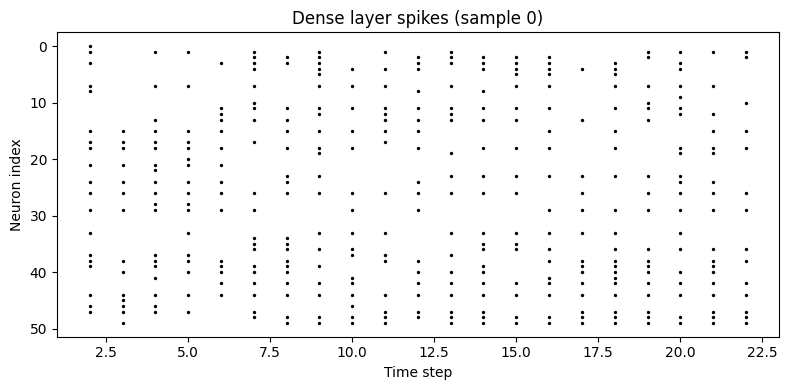

In [ ]:
import matplotlib.pyplot as plt


spk = net.spike_mon_enc    # [B, C, H, T] = [batch, neurons, 1, time]
snn1 = net.spike_mon_snn1  # [B, C, H, W, T] = [batch, neurons, 1, 1, time]
snn2 = net.spike_mon_snn2

# the spike output of snn 1st layer
spk = snn1[0]             # [C, 1, 1, T] for SNN output
spk = spk.squeeze(1).squeeze(1)      # [C, T]

# spk 是 0/1，轉成 (t, neuron) 的座標
neuron_idx, time_idx = spk.nonzero(as_tuple=True)

plt.figure(figsize=(8,4))
plt.scatter(time_idx, neuron_idx, s=2, c='k')
plt.xlabel('Time step')
plt.ylabel('Neuron index')
plt.title('Dense layer spikes (sample 0)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
trained_folder = 'Trained'
os.makedirs(trained_folder, exist_ok=True)

logs_folder = 'Trained'
os.makedirs(logs_folder, exist_ok=True)


for epoch in range(epochs):
    if epoch in steps:
        for param_group in optimizer.param_groups:    
            print('\nLearning rate reduction from', param_group['lr'])
            param_group['lr'] /= 10/3
        
    for i, (input, ground_truth) in enumerate(train_loader): # training loop
        assistant.train(input, ground_truth)
        print(f'\r[Epoch {epoch:3d}/{epochs}] {stats}', end='')
    
    for i, (input, ground_truth) in enumerate(test_loader): # testing loop
        assistant.test(input, ground_truth)
        print(f'\r[Epoch {epoch:3d}/{epochs}] {stats}', end='')
        
    if epoch%50==49: print() 
    # if stats.testing.best_loss:  
    #     torch.save(net.state_dict(), trained_folder + '/network.pt')
    stats.update()
    stats.save(trained_folder + '/')
    
    # gradient flow monitoring
    # net.grad_flow(trained_folder + '/')
    
    # checkpoint saves
    if epoch%10 == 0:
        torch.save({'net': net.state_dict(), 'optimizer': optimizer.state_dict()}, logs_folder + f'/checkpoint{epoch}.pt')    

[Epoch  28/1000] Train loss =     1.38629 (min =     1.38628)     accuracy = 0.00000 (max = 0.23236)  | Test  loss =     1.38629 (min =     1.38457)     accuracy = 0.00000 (max = 0.19571) 

KeyboardInterrupt: 